# load the نجس data

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [204]:
df = pd.read_csv("data/dirty_imbalanced_customer_risk.csv")
df["customer_id"] = (df["customer_id"].str.replace("CUST-", "", regex=False)).astype(int)

In [205]:
num_cols = df.select_dtypes(include="number")
cat_cols = df.select_dtypes(include=["str"])

In [206]:
list = []
for i in (cat_cols.columns):
    if df[i].value_counts().count() >= (0.75 * (len(df))):
        list.append(i)
        df.drop(columns=i, inplace=True)
        cat_cols.drop(columns=i, inplace=True)

print(f"we dont need these : {list}")

we dont need these : ['device_model', 'merchant_id', 'product_sku']


In [207]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10070 entries, 0 to 10069
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              10070 non-null  int32  
 1   signup_date              10070 non-null  str    
 2   age                      9063 non-null   float64
 3   income                   8996 non-null   float64
 4   balance                  8938 non-null   float64
 5   tenure_months            9192 non-null   float64
 6   transactions_30d         8966 non-null   float64
 7   avg_order_value          9141 non-null   float64
 8   days_since_last_login    9444 non-null   float64
 9   credit_score             9262 non-null   float64
 10  city                     9245 non-null   str    
 11  region                   9248 non-null   str    
 12  channel                  9384 non-null   str    
 13  device                   9600 non-null   str    
 14  plan_type                9290 non

# analyse the نجس data

## fill nan

In [208]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,RobustScaler

In [209]:
num_inmputer = Pipeline([
    ('inmputer', IterativeImputer(missing_values=np.nan))
])

cat_inmputer = Pipeline([
    ('inmputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
])

In [210]:
num_cols = pd.DataFrame(
    num_inmputer.fit_transform(num_cols),
    columns=num_cols.columns
)

cat_cols = pd.DataFrame(
    cat_inmputer.fit_transform(cat_cols),
    columns=cat_cols.columns
)

In [211]:
num_cols

,customer_id,age,income,balance,tenure_months,transactions_30d,avg_order_value,days_since_last_login,credit_score,postal_code,...,monthly_spend,credit_score_bucket_num,branch_code,error_code,noise_0,noise_1,noise_2,noise_3,noise_4,row_hash
0,1122.0,33.0,58262.542314,13938.395363,38.000000,16.000000,43.943404,2.538052,748.157082,72519.0,...,768.749998,700.00000,276.0,0.0,-0.863785,1.401215,0.604199,0.569925,-0.396574,4.845556e+09
1,319.0,37.0,29852.143451,13599.183963,28.000000,17.000000,69.190574,9.015687,540.698962,22515.0,...,1126.805920,500.00000,295.0,0.0,2.334931,0.762917,0.438334,1.725041,-0.051562,2.109521e+09
2,9134.0,41.0,49564.515162,-4516.216176,25.000000,14.000000,125.072752,14.432229,665.895819,11150.0,...,1816.816638,641.70957,246.0,101.0,-1.374020,0.695124,1.392604,-0.779588,-0.670708,7.465256e+09
3,1150.0,27.0,53296.677299,29335.525646,29.000000,18.000000,89.620114,15.055028,526.647695,39534.0,...,1630.198536,500.00000,172.0,0.0,0.280919,0.611413,0.864557,-2.848211,-0.290225,5.188169e+09
4,34.0,43.0,57359.477939,14058.543837,34.000000,21.000000,157.815658,27.741305,615.747544,11997.0,...,3207.417851,600.00000,280.0,0.0,-0.828827,-1.712375,-0.535332,-1.315098,-1.276986,5.941864e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10065,5735.0,49.0,31244.659687,-5000.000000,28.146290,17.000000,115.959939,13.991810,771.590535,15233.0,...,1955.730853,750.00000,231.0,0.0,-2.285806,0.161427,0.717828,0.590732,0.920598,3.506187e+09
10066,5192.0,23.0,36002.115415,581.522374,27.973387,20.000000,111.175799,10.678087,663.364445,89879.0,...,2074.061480,650.00000,294.0,0.0,-0.712610,-0.546772,1.571055,-0.517481,-0.846238,6.679895e+09
10067,5391.0,42.0,21377.510106,9680.092493,38.000000,6.904586,173.433083,6.830768,651.705824,54321.0,...,2408.886537,650.00000,220.0,0.0,-1.751601,0.548621,-2.097181,0.300905,0.715488,4.906660e+09
10068,861.0,51.0,49087.311852,28656.525592,32.000000,13.000000,20.855790,3.714892,664.689449,35087.0,...,263.538297,650.00000,182.0,0.0,-0.064318,-0.190757,-1.114975,1.962214,-0.048635,7.765819e+09


## handle outliers


In [212]:
cols = num_cols.drop(columns=["account_frozen", "fraud_flag", "error_code", "customer_id"])

In [213]:
for col in cols.columns:
    q1 = cols[col].quantile(0.25)
    q3 = cols[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    cols = cols[
        (cols[col] >= lower) &
        (cols[col] <= upper)
    ]

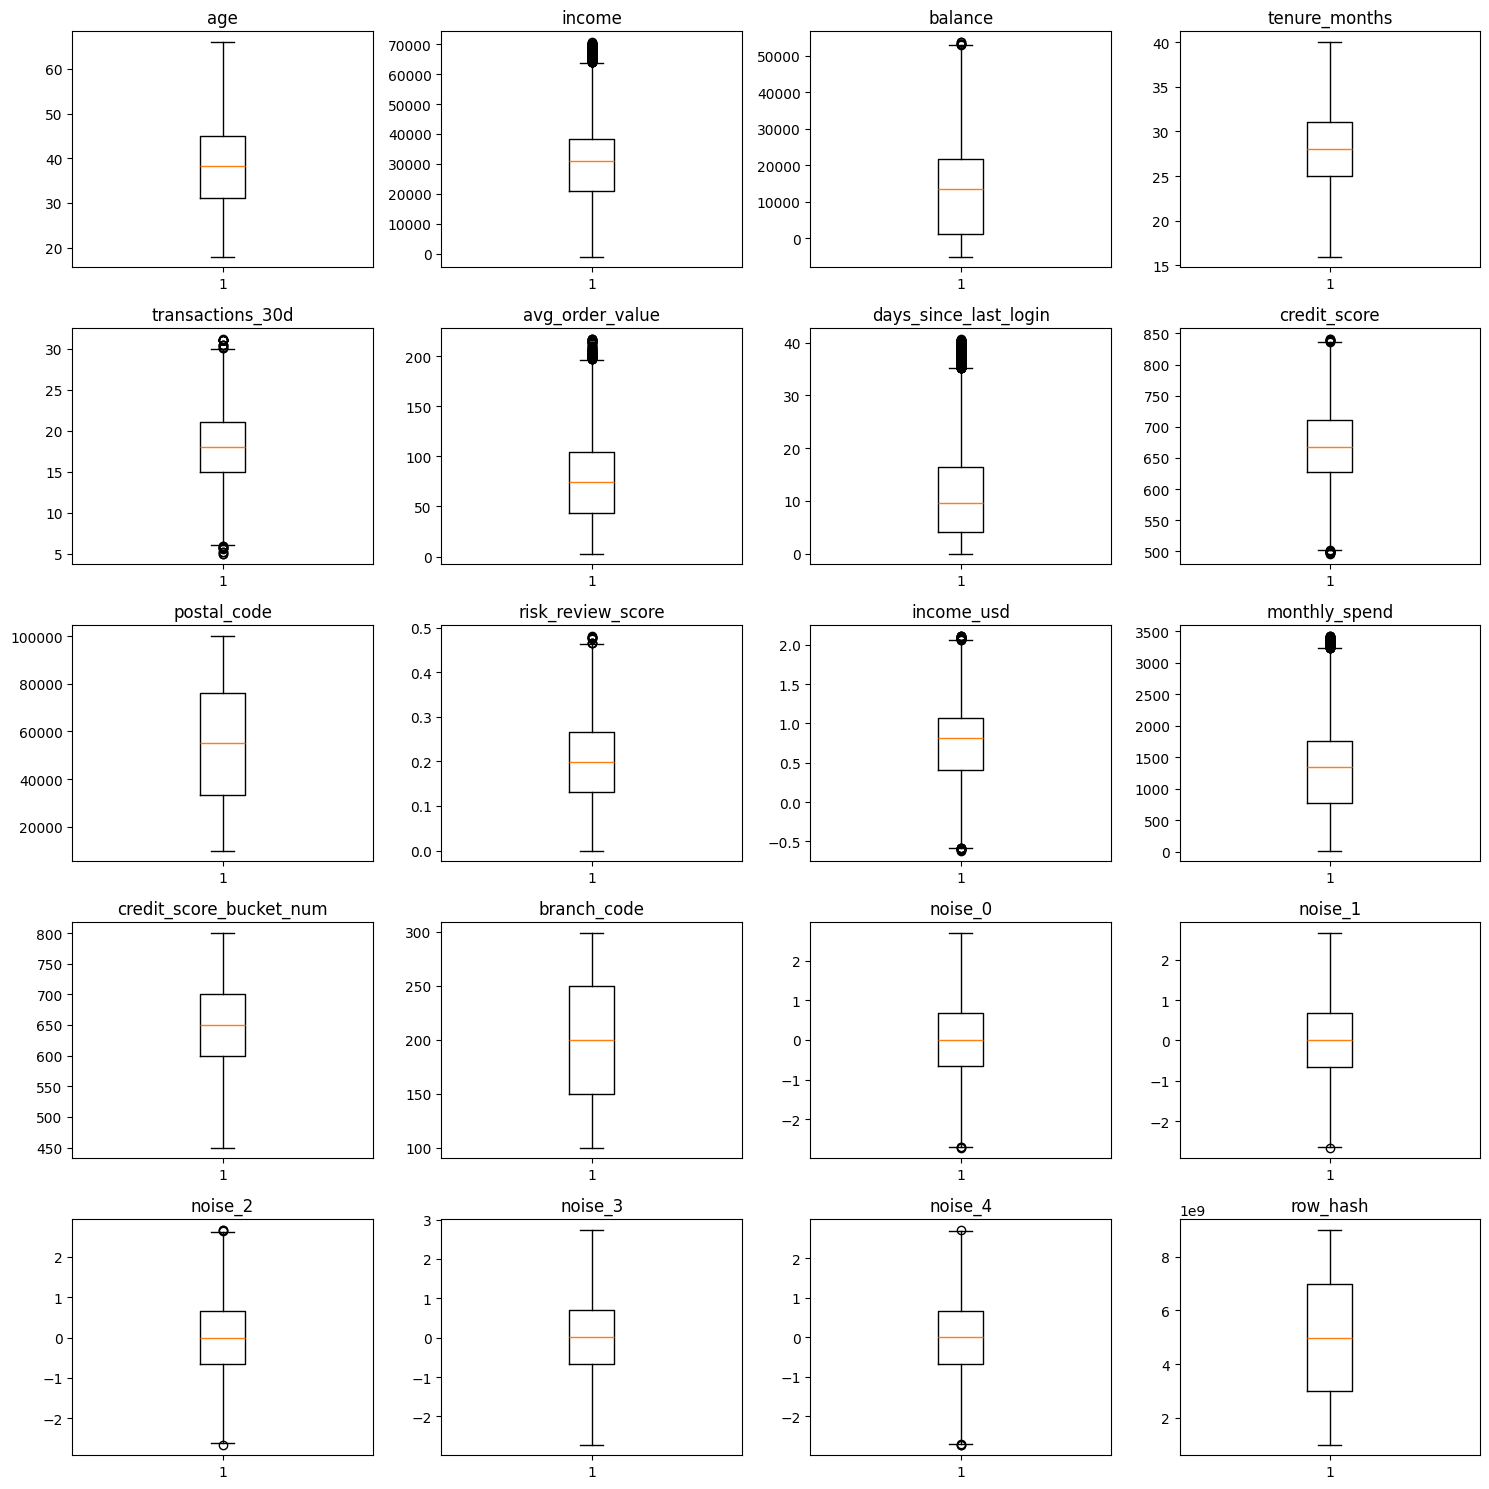

In [214]:
fig, axs = plt.subplots(5, 4, figsize=(15, 15))

for idx in range(20):
    axs.flat[idx].boxplot(
        (cols.iloc[:, idx]),
    )

    axs.flat[idx].set_title(cols.columns[idx])

plt.tight_layout()
plt.show()

In [215]:
num_cols = pd.concat(
    [
        cols,
        num_cols[["account_frozen", "fraud_flag", "error_code", "customer_id"]]
    ],
    axis=1
).dropna()

In [216]:
num_cols.describe()

,age,income,balance,tenure_months,transactions_30d,avg_order_value,days_since_last_login,credit_score,postal_code,risk_review_score,...,noise_0,noise_1,noise_2,noise_3,noise_4,row_hash,account_frozen,fraud_flag,error_code,customer_id
count,7103.000000,7103.000000,7103.000000,7103.000000,7103.000000,7103.000000,7103.000000,7103.000000,7103.000000,7103.000000,...,7103.000000,7103.000000,7103.000000,7103.000000,7103.000000,7.103000e+03,7103.000000,7103.000000,7103.000000,7103.000000
mean,38.188422,31811.139273,13135.650174,27.961415,18.049951,77.490209,11.749118,668.955747,54872.700819,0.198738,...,-0.008945,0.007135,-0.000749,0.005561,-0.002316,4.974681e+09,0.019851,0.038434,79.515838,4979.045333
std,10.629582,12943.955707,13951.406650,4.699919,4.478677,43.780167,9.443073,64.213409,25191.639237,0.096761,...,0.981023,0.968041,0.957216,0.980202,0.978599,2.315970e+09,0.139497,0.192256,148.498988,2882.728252
min,18.000000,-1000.000000,-5000.000000,16.000000,5.000000,3.000000,0.006487,496.494871,10001.000000,0.000000,...,-2.718401,-2.658924,-2.655487,-2.715326,-2.710620,1.000019e+09,0.000000,0.000000,0.000000,1.000000
25%,31.000000,21032.275212,1061.088477,25.000000,15.000000,43.110297,4.041296,627.261678,33448.000000,0.131195,...,-0.670104,-0.655313,-0.655731,-0.677642,-0.673756,2.987170e+09,0.000000,0.000000,0.000000,2478.500000
50%,38.153358,31075.789051,13564.578181,28.000000,18.000000,74.036582,9.682906,667.056201,54937.155147,0.198230,...,-0.012072,0.017263,-0.011867,0.019625,-0.001231,4.956036e+09,0.000000,0.000000,0.000000,4946.000000
75%,45.000000,38181.066936,21780.187165,31.000000,21.000000,104.509790,16.472704,710.982232,76009.000000,0.264873,...,0.680231,0.679244,0.664055,0.690246,0.676394,6.984933e+09,0.000000,0.000000,101.000000,7470.500000
max,66.000000,70751.869256,53703.717992,40.000000,31.161813,216.931672,40.667977,840.868109,99991.000000,0.480989,...,2.702047,2.664813,2.666222,2.733107,2.715295,8.999941e+09,1.000000,1.000000,500.000000,10000.000000


# cat cols

In [217]:
cat_cols["signup_date"] = pd.to_datetime(cat_cols["signup_date"])

cat_cols["year"] = cat_cols["signup_date"].dt.year
cat_cols["month"] = cat_cols["signup_date"].dt.month
cat_cols["day"] = cat_cols["signup_date"].dt.day

cat_cols = cat_cols.drop(columns="signup_date")


In [218]:
cat_cols["city"] = (
    cat_cols["city"]
    .str.strip()
    .str.lower()
    .str.replace(" ", "", regex=False)
)

cat_cols["city"] = cat_cols["city"].replace({
    "isfahan": "Isfahan",
    "esfahan": "Isfahan",
    "shiraz": "Shiraz",
    "mashhad": "Mashhad",
    "tabriz": "Tabriz",
    "tehran": "Tehran"
})

In [219]:
cat_cols

,city,region,channel,device,plan_type,merchant_category,signup_source,notes,year,month,day
0,rasht,central,web,windows,basic,electronics,ad,coupon applied,2022,2,11
1,arak,south,web,ios,basic,grocery,ad,ok,2024,10,23
2,ahvaz,east,web,linux,gold,gaming,organic,verified,2022,9,14
3,Tehran,north,web,android,gold,education,organic,late payment,2021,6,1
4,qom,east,mobile,ios,platinum,grocery,organic,ok,2025,8,25
...,...,...,...,...,...,...,...,...,...,...,...
10065,kerman,central,mobile,windows,basic,home,organic,manual review,2024,2,5
10066,sari,central,mobile,linux,silver,fashion,unknown,suspicious pattern,2023,5,28
10067,yazd,central,web,macos,basic,grocery,organic,coupon applied,2023,3,1
10068,rasht,west,mobile,macos,basic,electronics,unknown,verified,2025,1,1


In [220]:
freq = cat_cols["city"].value_counts(normalize=True)
cat_cols["city"] = cat_cols["city"].map(freq)

In [221]:
cat_cols["plan_type"] = cat_cols["plan_type"].replace({
    "basic": 0,
    "silver": 1,
    "gold": 2,
    "platinum": 3,

})

In [222]:
one_hot = pd.get_dummies(cat_cols[['region', 'channel', 'device']]).astype(int)
cat_cols = pd.concat(
    [
        cat_cols,
        one_hot
    ],
    axis=1
)

In [223]:
cat_cols["is_suspicious"] = (cat_cols["notes"] == "suspicious pattern").astype(int)

In [224]:
cat_cols = cat_cols.drop(columns=["notes", "region", "channel", "device", "signup_source", "merchant_category"])

In [225]:
cat_cols["plan_type"] = cat_cols["plan_type"].astype(int)

## merge the datasets and start model shits

In [226]:
cat_cols["customer_id"] = df.loc[cat_cols.index, "customer_id"]

final = pd.merge(
    num_cols,
    cat_cols,
    on="customer_id",
    how="inner"
).sort_values("customer_id")

## pca

In [235]:
X = final.drop(columns="fraud_flag")
y = final["fraud_flag"]

## train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, ytrain , y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale data


In [ ]:
from sklearn.preprocessing import StandardScaler
cols = num_cols.drop(columns=["account_frozen", "fraud_flag", "error_code"])

scaler = StandardScaler()

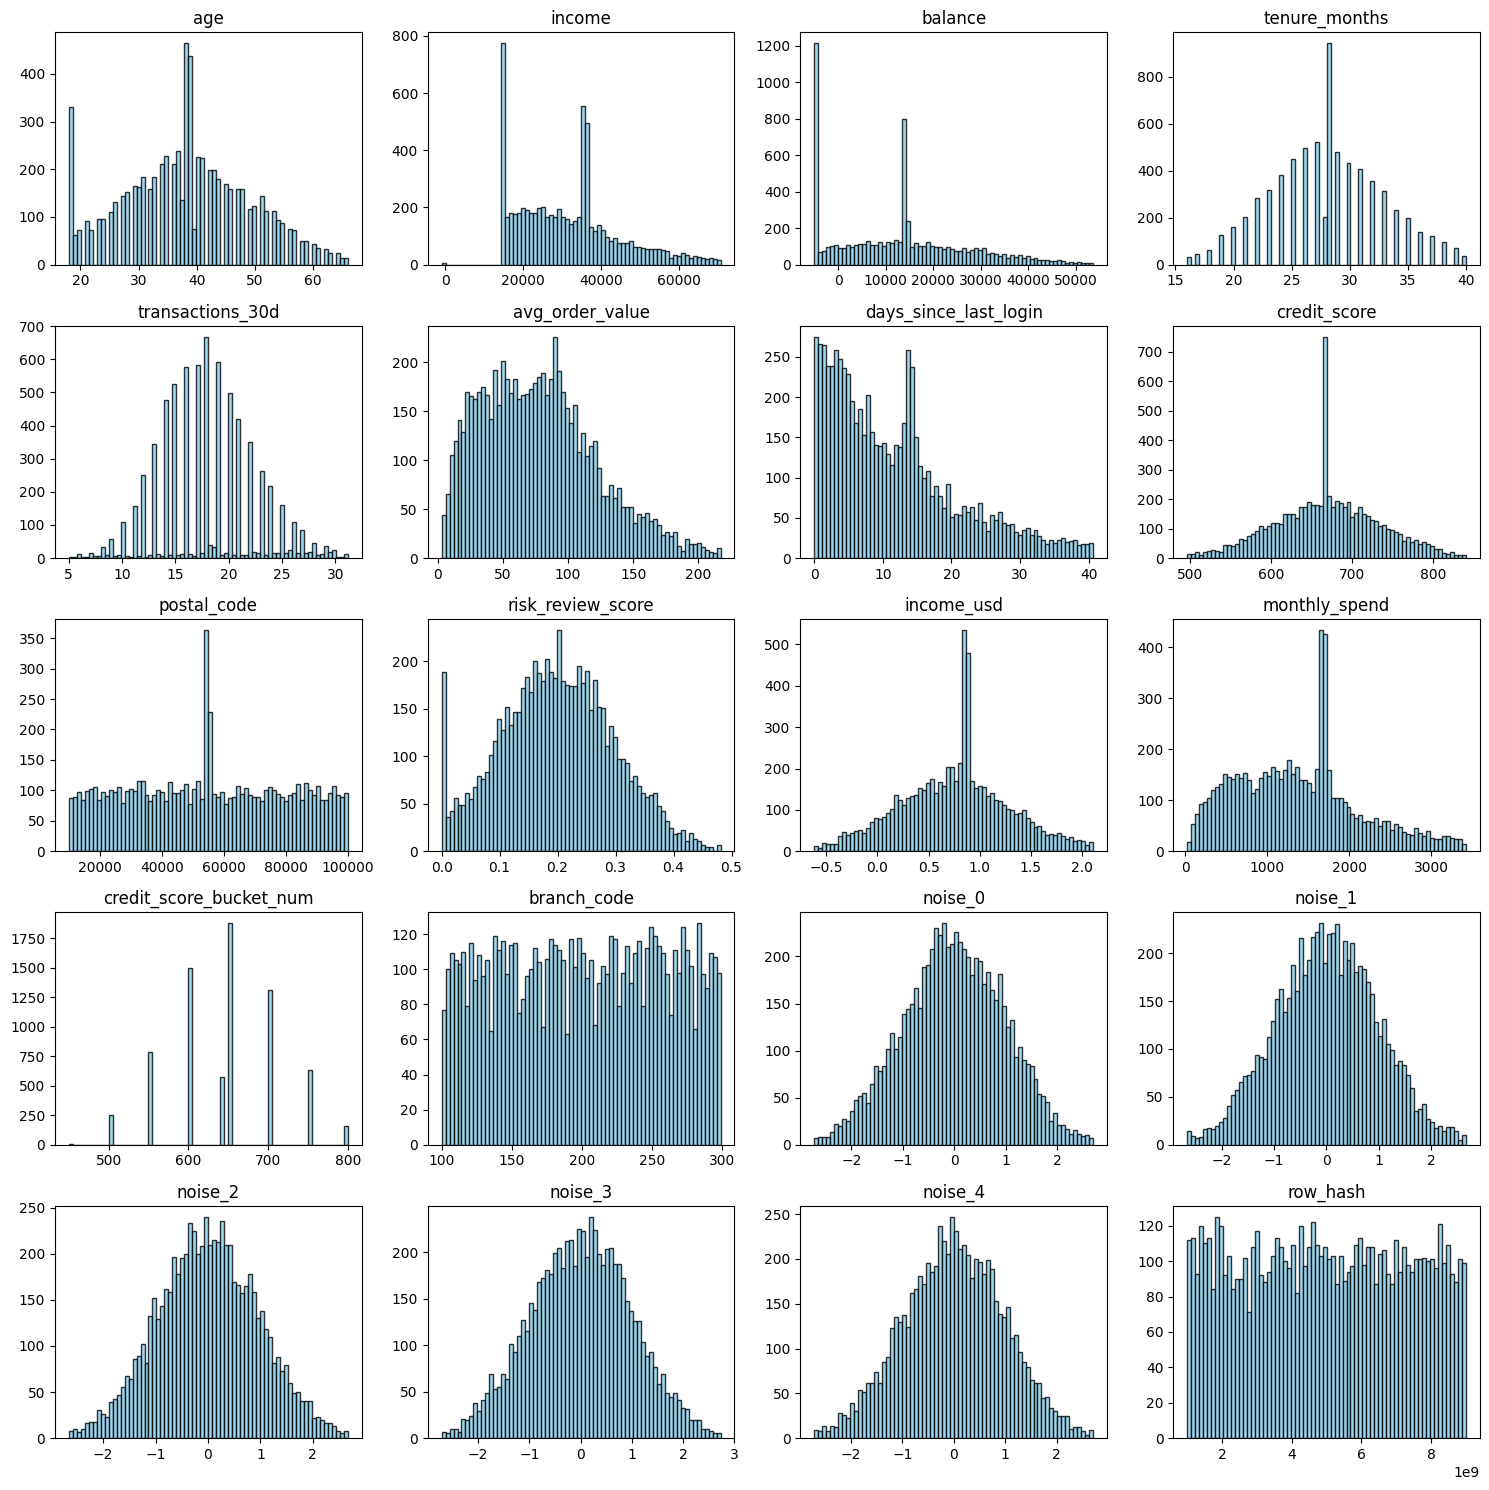

In [ ]:

fig, axs = plt.subplots(5, 4, figsize=(15, 15))

for idx in range(20):
    axs.flat[idx].hist(
        (cols.iloc[:, idx]),
        bins=70,
        color="skyblue",
        edgecolor="black",
        alpha=0.8,
        label = f'sqrt on feature {cols.iloc[:, idx]}'
    )

    axs.flat[idx].set_title(num_cols.columns[idx])

plt.tight_layout()
plt.show()

<Axes: >

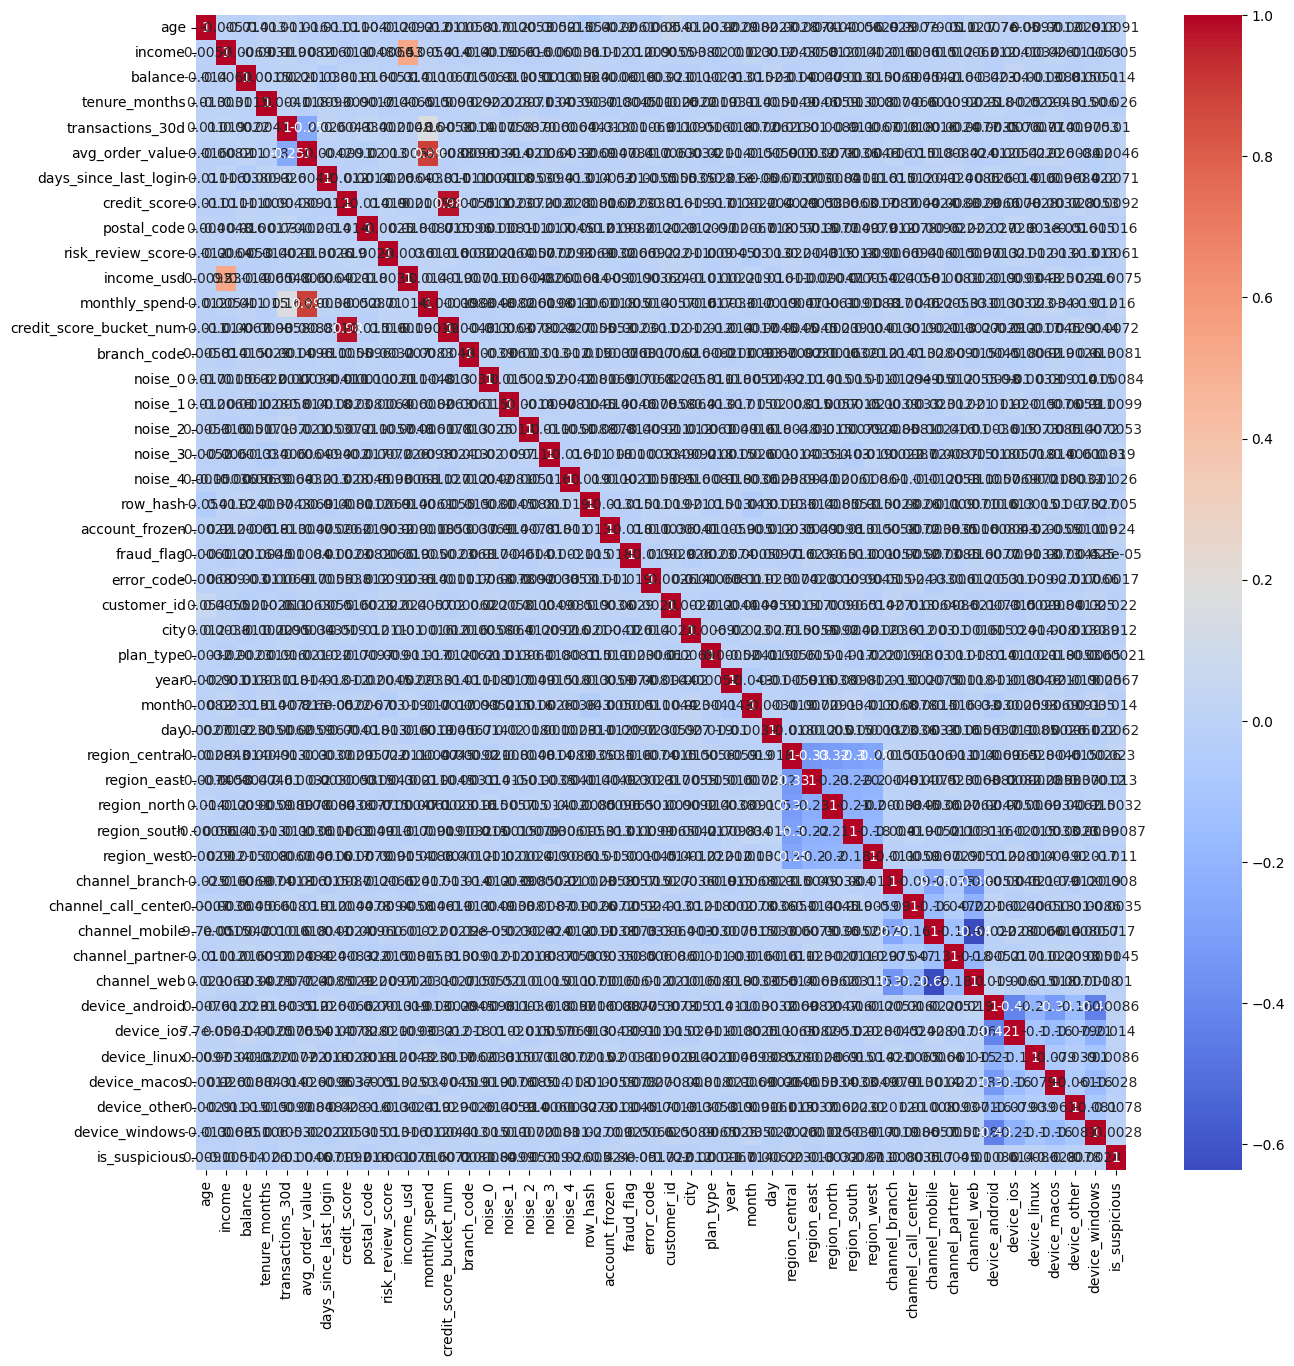

In [241]:
import seaborn as sns

corr = final.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr,cmap="coolwarm",
            annot=True)